In [2]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Load Dataset
df = pd.read_csv("creditcard.csv")

In [6]:
#Simple information about dataset
df.head()
df.tail()
df.sample(5)
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
#Checking missing values
df.isnull().sum()
#Checking duplicate values
df.duplicated().sum()
#Removing Duplicates
df = df.drop_duplicates()


In [10]:
# Checking the distribution of fraud and non-fraud transactions

class_distribution = df['Class'].value_counts()

print("Class Distribution:")
print(class_distribution)

Class Distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [11]:
# Calculating percentage of each class

class_percentage = df['Class'].value_counts(normalize=True) * 100

print("Class Percentage Distribution:")
print(class_percentage)

Class Percentage Distribution:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


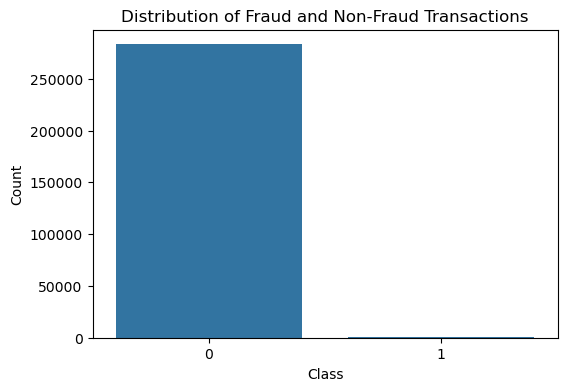

In [12]:
# Visualizing class imbalance

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)

plt.title("Distribution of Fraud and Non-Fraud Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [13]:
# Separating features and target variable

X = df.drop('Class', axis=1)
y = df['Class']

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (283726, 30)
Target Variable Shape: (283726,)


In [14]:
# Splitting dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

Training Features Shape: (226980, 30)
Testing Features Shape: (56746, 30)


In [15]:
# Importing SMOTE

from imblearn.over_sampling import SMOTE

# Creating SMOTE object

smote = SMOTE(random_state=42)

# Applying SMOTE on training data

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Checking class distribution before and after SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [21]:
# Importing Logistic Regression

from sklearn.linear_model import LogisticRegression

# Creating and training the model
lr_model = LogisticRegression(
    max_iter=5000,
    solver='liblinear',
    random_state=42
)

lr_model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=5000, random_state=42, solver='liblinear')

In [17]:
# Making predictions

y_pred_lr = lr_model.predict(X_test)

y_prob_lr = lr_model.predict_proba(X_test)[:,1]

In [18]:
# Evaluating Logistic Regression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_lr))

Confusion Matrix:
[[56008   643]
 [   12    83]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.11      0.87      0.20        95

    accuracy                           0.99     56746
   macro avg       0.56      0.93      0.60     56746
weighted avg       1.00      0.99      0.99     56746


ROC-AUC Score:
0.9536144203335474


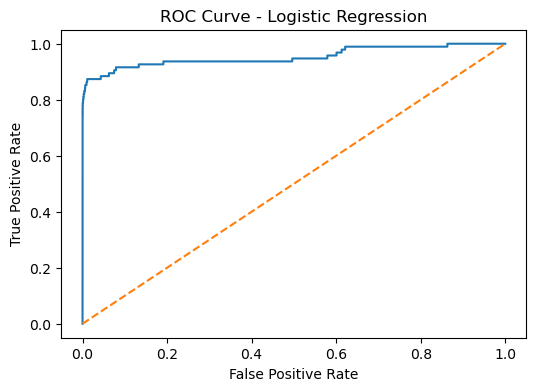

In [19]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.show()

In [25]:
# Importing Random Forest

from sklearn.ensemble import RandomForestClassifier

# Creating and training the model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [26]:
# Making predictions

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [27]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_rf))

Confusion Matrix:
[[56642     9]
 [   22    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.77      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746


ROC-AUC Score:
0.9608938941942773


In [3]:
# Comparing both models

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [0.11, 0.89],
    'Recall': [0.87, 0.77],
    'F1-Score': [0.20, 0.82],
    'ROC-AUC': [0.9536, 0.9609]
})

comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.11,0.87,0.20,0.9536
1,Random Forest,0.89,0.77,0.82,0.9609
